<a href="https://colab.research.google.com/github/harishmk31/24ADI003_24BAD031/blob/main/scenario1_exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HARISH MK
24BAD031

 Dataset Shape  : (120, 6)
 Columns        : ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin', 'Outcome']

 First 5 Rows:
   Glucose   BMI  Age  BloodPressure  Insulin  Outcome
0      182  21.1   45             99      100        1
1      131  35.6   67             92      199        1
2      172  19.6   68             68      234        1
3       94  39.7   21            102       83        0
4      186  35.0   20            113       61        1

 Class Distribution:
Outcome
Diabetes (1)       74
No Diabetes (0)    46
Name: count, dtype: int64

 Missing Values :
Glucose          0
BMI              0
Age              0
BloodPressure    0
Insulin          0
Outcome          0
dtype: int64

 Features Used  : ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin']
Train Size: 96  |  Test Size: 24

  DECISION TREE
  Accuracy : 95.83%

              precision    recall  f1-score   support

 No Diabetes       0.90      1.00      0.95         9
    Diabetes       1.00  

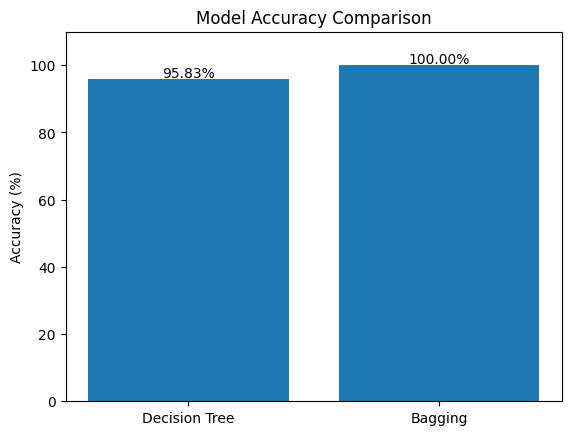

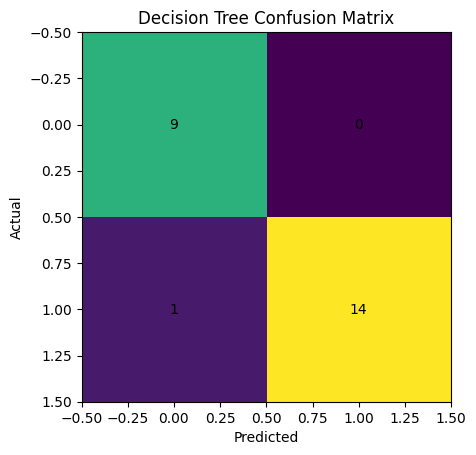

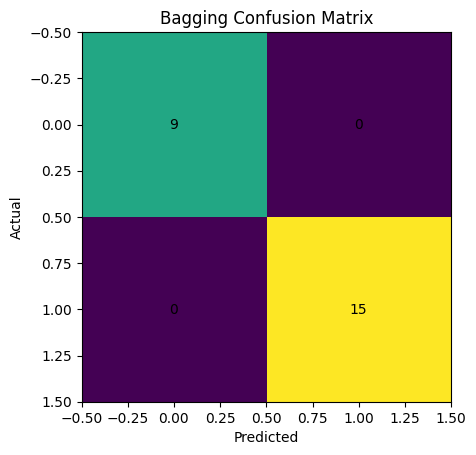

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("HARISH MK")
print("24BAD031")

df = pd.read_csv("diabetes_bagging.csv")

print(f"\n Dataset Shape  : {df.shape}")
print(f" Columns        : {list(df.columns)}")
print(f"\n First 5 Rows:\n{df.head()}")
print(f"\n Class Distribution:\n{df['Outcome'].value_counts().rename({0:'No Diabetes (0)', 1:'Diabetes (1)'})}")
print(f"\n Missing Values :\n{df.isnull().sum()}")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print(f"\n Features Used  : {list(X.columns)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train Size: {X_train.shape[0]}  |  Test Size: {X_test.shape[0]}")

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_cm  = confusion_matrix(y_test, y_pred_dt)

print("\n  DECISION TREE")
print(f"  Accuracy : {dt_acc * 100:.2f}%\n")

print(classification_report(
    y_test, y_pred_dt,
    target_names=["No Diabetes", "Diabetes"]
))

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)

bag_acc = accuracy_score(y_test, y_pred_bag)
bag_cm  = confusion_matrix(y_test, y_pred_bag)

print("\n  BAGGING CLASSIFIER (50 Trees)")
print("─" * 50)
print(f"  Accuracy : {bag_acc * 100:.2f}%\n")

print(classification_report(
    y_test,
    y_pred_bag,
    target_names=["No Diabetes", "Diabetes"]
))

improvement = (bag_acc - dt_acc) * 100

print("=" * 50)
print("  ACCURACY COMPARISON")
print("=" * 50)
print(f"  Decision Tree  : {dt_acc  * 100:.2f}%")
print(f"  Bagging        : {bag_acc * 100:.2f}%")
print(f"  Improvement    : {improvement:+.2f}%")
print("=" * 50)

models = ["Decision Tree", "Bagging"]
accuracies = [dt_acc * 100, bag_acc * 100]

plt.bar(models, accuracies)

for i, val in enumerate(accuracies):
    plt.text(i, val + 0.5, f"{val:.2f}%", ha="center")

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.show()

def plot_cm(cm, title):
    plt.imshow(cm)
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(dt_cm, "Decision Tree Confusion Matrix")
plot_cm(bag_cm, "Bagging Confusion Matrix")